# Proprioceptive sensing — object stiffness estimation

The hand squeezes a grasped object with the four fingers held at constant stiffness
$k_{\rm hold}$ = {K_TIP_HOLD} N/m (clamping side).  The thumb alone sweeps through
increasing tip stiffness levels and the resulting position–force finite difference
estimates object compliance without external force sensors.

---

## Why $\Delta x / \Delta F$ recovers $C_O$

At equilibrium, the VMC spring force equals the object reaction force.  Taking the
finite difference between the gentle baseline ($k_1$) and each probe level ($k_2 > k_1$):

$$\Delta x_\text{thumb} = x(k_2) - x(k_1), \qquad \Delta F_\text{thumb} = F(k_2) - F(k_1)$$

$$C_O = \frac{\|\Delta x_\text{thumb}\|}{\|\Delta F_\text{thumb}\|}$$

The hand compliance cancels exactly; lower $C_O$ means stiffer object.

In [241]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os, sys

sys.path.insert(0, os.path.join('../..'))
sys.path.insert(0, '.')
from hand_config import K_TIP_GENTLE, K_TIP_SWEEP, K_TIP_HOLD, N_RUNS, OBJECTS, FINGERTIPS

OUTPUT_DIR = os.path.join('outputs', 'object_stiffness_hand')

K_TIP_GENTLE = float(K_TIP_GENTLE)
K_TIP_SWEEP  = [float(k) for k in K_TIP_SWEEP]

OBJECT_LABELS = ['Sphere', 'Sponge', 'Yarn']
OBJ_COLORS    = {'hard': '#D55E00', 'medium': '#E69F00', 'soft': '#56B4E9'}

In [242]:
def load_runs(obj):
    """Load all run CSV files for an object; fall back to the single-file (video) naming."""
    dfs = []
    for r in range(1, N_RUNS + 1):
        p = os.path.join(OUTPUT_DIR, f'object_stiffness_hand_{obj}_run{r}.csv')
        if os.path.exists(p):
            dfs.append(pd.read_csv(p))
    if not dfs:
        p = os.path.join(OUTPUT_DIR, f'object_stiffness_hand_{obj}.csv')
        if os.path.exists(p):
            dfs.append(pd.read_csv(p))
    return dfs


def _thumb_baseline(df):
    gentle = df[df['k_tip_Npm'] == K_TIP_GENTLE]
    pos_b  = gentle[['tip_thumb_x_m', 'tip_thumb_y_m', 'tip_thumb_z_m']].median().to_numpy()
    F_b    = gentle[['force_1st_thumb_x_N', 'force_1st_thumb_y_N', 'force_1st_thumb_z_N']].median().to_numpy()
    return pos_b, F_b


def compliance_per_run(dfs):
    """Median-based C_O [m/N] for each run at each sweep level.
    Returns dict: k -> 1-D array of length n_runs."""
    out = {k: [] for k in K_TIP_SWEEP}
    for df in dfs:
        pos_b, F_b = _thumb_baseline(df)
        for k in K_TIP_SWEEP:
            sub  = df[df['k_tip_Npm'] == k]
            pos  = sub[['tip_thumb_x_m', 'tip_thumb_y_m', 'tip_thumb_z_m']].median().to_numpy()
            F1   = sub[['force_1st_thumb_x_N', 'force_1st_thumb_y_N', 'force_1st_thumb_z_N']].median().to_numpy()
            nF   = np.linalg.norm(F1 - F_b)
            out[k].append(np.linalg.norm(pos - pos_b) / nF if nF > 1e-12 else np.nan)
    return {k: np.array(v) for k, v in out.items()}


def displacement_per_run(dfs):
    """Median thumb displacement [m] from baseline per run at each sweep level."""
    out = {k: [] for k in K_TIP_SWEEP}
    for df in dfs:
        pos_b, _ = _thumb_baseline(df)
        for k in K_TIP_SWEEP:
            sub = df[df['k_tip_Npm'] == k]
            pos = sub[['tip_thumb_x_m', 'tip_thumb_y_m', 'tip_thumb_z_m']].median().to_numpy()
            out[k].append(np.linalg.norm(pos - pos_b))
    return {k: np.array(v) for k, v in out.items()}


def force_per_run(dfs):
    """Median thumb force change [N] from baseline per run at each sweep level."""
    out = {k: [] for k in K_TIP_SWEEP}
    for df in dfs:
        _, F_b = _thumb_baseline(df)
        for k in K_TIP_SWEEP:
            sub = df[df['k_tip_Npm'] == k]
            F1  = sub[['force_1st_thumb_x_N', 'force_1st_thumb_y_N', 'force_1st_thumb_z_N']].median().to_numpy()
            out[k].append(np.linalg.norm(F1 - F_b))
    return {k: np.array(v) for k, v in out.items()}


# ── Load data ──────────────────────────────────────────────────────────────────
data = {}
print('Loading data:')
for obj in OBJECTS:
    dfs = load_runs(obj)
    if not dfs:
        print(f'  {obj:<10s}: no data')
        continue
    data[obj] = dict(
        dfs        = dfs,
        compliance = compliance_per_run(dfs),
        displ      = displacement_per_run(dfs),
        force      = force_per_run(dfs),
    )
    n = len(dfs)
    c_top = data[obj]['compliance'][max(K_TIP_SWEEP)]
    print(f'  {obj:<10s}: {n} run(s)  C_O at K_top: {np.nanmean(c_top)*1e3:.1f} ± {np.nanstd(c_top)*1e3:.2f} mm/N')

Loading data:
  hard      : 5 run(s)  C_O at K_top: 22.7 ± 1.66 mm/N
  medium    : 4 run(s)  C_O at K_top: 20.0 ± 2.22 mm/N
  soft      : 4 run(s)  C_O at K_top: 28.3 ± 5.02 mm/N


## Thumb object compliance $C_O$ vs $k_{tip}$

$C_O = \|\Delta x_{\rm thumb}\| / \|\Delta F_{\rm thumb}\|$ — lower = stiffer object. Dashed lines = individual trials, solid = mean, band = ±1 std.

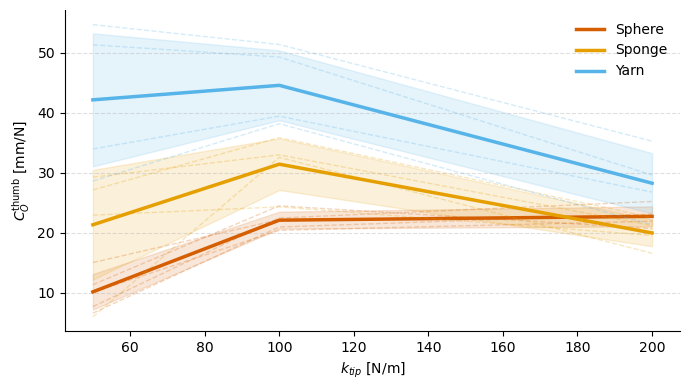

In [243]:
def _sweep_plot(ax, per_run_dict, scale, obj, ylabel):
    """Plot per-run dashed lines + mean solid + std band for one object."""
    k_levels = sorted(per_run_dict.keys())
    vals     = np.array([per_run_dict[k] * scale for k in k_levels])  # (n_k, n_runs)
    mean     = np.nanmean(vals, axis=1)
    std      = np.nanstd(vals,  axis=1)
    color    = OBJ_COLORS[obj]
    name     = OBJECT_LABELS[OBJECTS.index(obj)] if obj in OBJECTS else obj
    # individual runs
    for r in range(vals.shape[1]):
        ax.plot(k_levels, vals[:, r], color=color, lw=1.0,
                linestyle='--', alpha=0.25)
    # mean ± std
    ax.fill_between(k_levels, mean - std, mean + std, color=color, alpha=0.15)
    ax.plot(k_levels, mean, color=color, lw=2.5, linestyle='-', label=name)

fig, ax = plt.subplots(figsize=(7, 4))
for obj in OBJECTS:
    if obj not in data:
        continue
    _sweep_plot(ax, data[obj]['compliance'], 1e3, obj, r'$C_O^{\mathrm{thumb}}$ [mm/N]')
ax.set_xlabel(r'$k_{tip}$ [N/m]')
ax.set_ylabel(r'$C_O^{\mathrm{thumb}}$ [mm/N]')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
fig.tight_layout()
os.makedirs(OUTPUT_DIR, exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, 'thumb_compliance_sweep.pdf'), bbox_inches='tight')
plt.show()

## Thumb tip displacement $\|\Delta x_{\rm thumb}\|$ vs $k_{tip}$

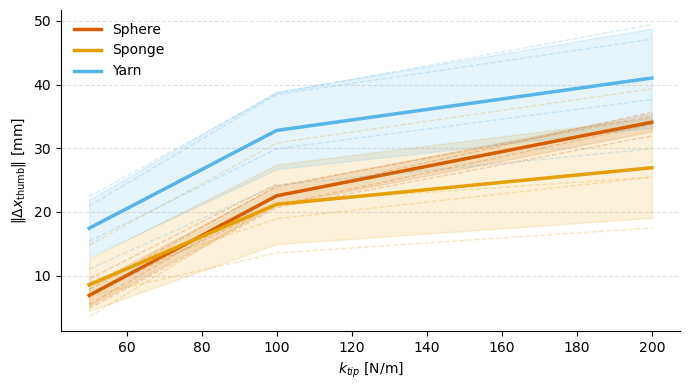

In [244]:
def _sweep_plot(ax, per_run_dict, scale, obj, ylabel):
    """Plot per-run dashed lines + mean solid + std band for one object."""
    k_levels = sorted(per_run_dict.keys())
    vals     = np.array([per_run_dict[k] * scale for k in k_levels])  # (n_k, n_runs)
    mean     = np.nanmean(vals, axis=1)
    std      = np.nanstd(vals,  axis=1)
    color    = OBJ_COLORS[obj]
    name     = OBJECT_LABELS[OBJECTS.index(obj)] if obj in OBJECTS else obj
    # individual runs
    for r in range(vals.shape[1]):
        ax.plot(k_levels, vals[:, r], color=color, lw=1.0,
                linestyle='--', alpha=0.25)
    # mean ± std
    ax.fill_between(k_levels, mean - std, mean + std, color=color, alpha=0.15)
    ax.plot(k_levels, mean, color=color, lw=2.5, linestyle='-', label=name)

fig, ax = plt.subplots(figsize=(7, 4))
for obj in OBJECTS:
    if obj not in data:
        continue
    _sweep_plot(ax, data[obj]['displ'], 1e3, obj, r'$\|\Delta x\|$ [mm]')
ax.set_xlabel(r'$k_{tip}$ [N/m]')
ax.set_ylabel(r'$\|\Delta x_{\mathrm{thumb}}\|$ [mm]')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'thumb_displacement_sweep.pdf'), bbox_inches='tight')
plt.show()

## Thumb contact force $\|\Delta F_{\rm thumb}\|$ vs $k_{tip}$

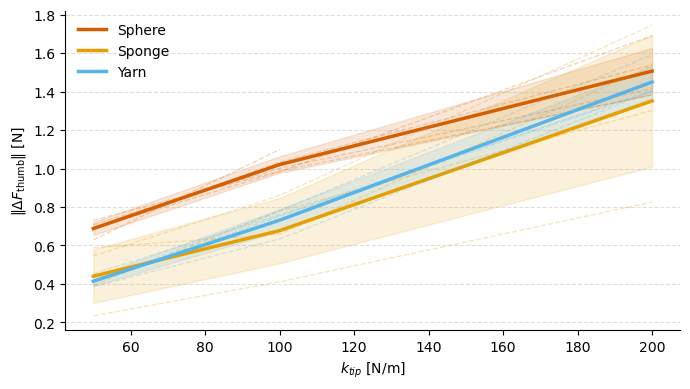

In [245]:
def _sweep_plot(ax, per_run_dict, scale, obj, ylabel):
    """Plot per-run dashed lines + mean solid + std band for one object."""
    k_levels = sorted(per_run_dict.keys())
    vals     = np.array([per_run_dict[k] * scale for k in k_levels])  # (n_k, n_runs)
    mean     = np.nanmean(vals, axis=1)
    std      = np.nanstd(vals,  axis=1)
    color    = OBJ_COLORS[obj]
    name     = OBJECT_LABELS[OBJECTS.index(obj)] if obj in OBJECTS else obj
    # individual runs
    for r in range(vals.shape[1]):
        ax.plot(k_levels, vals[:, r], color=color, lw=1.0,
                linestyle='--', alpha=0.25)
    # mean ± std
    ax.fill_between(k_levels, mean - std, mean + std, color=color, alpha=0.15)
    ax.plot(k_levels, mean, color=color, lw=2.5, linestyle='-', label=name)

fig, ax = plt.subplots(figsize=(7, 4))
for obj in OBJECTS:
    if obj not in data:
        continue
    _sweep_plot(ax, data[obj]['force'], 1.0, obj, r'$\|\Delta F\|$ [N]')
ax.set_xlabel(r'$k_{tip}$ [N/m]')
ax.set_ylabel(r'$\|\Delta F_{\mathrm{thumb}}\|$ [N]')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'thumb_force_sweep.pdf'), bbox_inches='tight')
plt.show()

## Object classification by thumb compliance

$C_O^{\rm thumb}$ at the highest $k_{tip}$ — each trial shown as a dot, filled marker = mean ± std. Lower = stiffer.

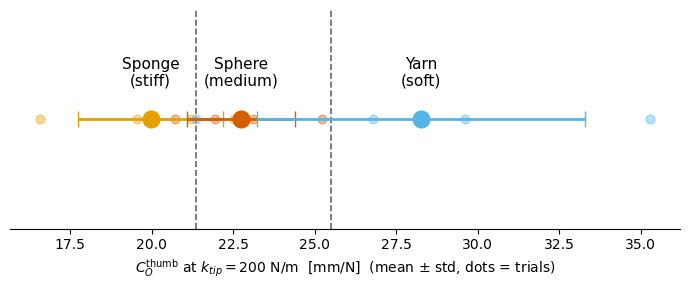

Object classification:
  Sponge      19.98 ± 2.217 mm/N  --> stiff
  Sphere      22.74 ± 1.663 mm/N  --> medium
  Yarn        28.26 ± 5.021 mm/N  --> soft


In [246]:
K_TOP = max(K_TIP_SWEEP)

C_O_runs = {obj: data[obj]['compliance'][K_TOP] * 1e3
            for obj in OBJECTS if obj in data and K_TOP in data[obj]['compliance']}

if not C_O_runs:
    print('No data — skipping classification.')
else:
    sorted_objs = sorted(C_O_runs, key=lambda o: np.nanmean(C_O_runs[o]))
    cluster_labels = {sorted_objs[i]: lbl
                      for i, lbl in enumerate(['stiff', 'medium', 'soft'][:len(sorted_objs)])}
    means = [np.nanmean(C_O_runs[o]) for o in sorted_objs]
    thresholds = [(means[i] + means[i+1]) / 2 for i in range(len(means) - 1)]

    fig, ax = plt.subplots(figsize=(7, 3))
    for obj in sorted_objs:
        vals  = C_O_runs[obj]
        m, s  = float(np.nanmean(vals)), float(np.nanstd(vals))
        color = OBJ_COLORS[obj]
        oi    = OBJECTS.index(obj)
        name  = OBJECT_LABELS[oi] if oi < len(OBJECT_LABELS) else obj
        lbl   = cluster_labels[obj]
        # individual trial dots
        ax.scatter(vals, np.zeros_like(vals), color=color, s=40, alpha=0.4, zorder=4)
        # mean with std error bar
        ax.errorbar([m], [0], xerr=[[s], [s]],
                    fmt='o', color=color, ms=12, capsize=6, lw=2, zorder=5)
        ax.annotate(f'{name}\n({lbl})', (m, 0),
                    textcoords='offset points', xytext=(0, 24),
                    ha='center', fontsize=11)
    for thr in thresholds:
        ax.axvline(thr, color='0.4', lw=1.2, linestyle='--')

    ax.set_xlabel(r'$C_O^{\mathrm{thumb}}$ at $k_{tip}=' + f'{K_TOP:.0f}$'
                  + r' N/m  [mm/N]  (mean $\pm$ std, dots = trials)')
    ax.set_yticks([])
    ax.spines[['left', 'top', 'right']].set_visible(False)
    fig.tight_layout()
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    fig.savefig(os.path.join(OUTPUT_DIR, 'object_classification.pdf'), bbox_inches='tight')
    plt.show()

    print('Object classification:')
    for obj in sorted_objs:
        oi    = OBJECTS.index(obj)
        name  = OBJECT_LABELS[oi] if oi < len(OBJECT_LABELS) else obj
        m, s  = np.nanmean(C_O_runs[obj]), np.nanstd(C_O_runs[obj])
        print(f'  {name:<10s}  {m:.2f} ± {s:.3f} mm/N  --> {cluster_labels[obj]}')